In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

In [24]:
df = pd.read_csv('../Dataset/forest+fires/forestfires.csv')
df

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00


In [12]:
df['area_norm'] = np.log1p(df['area'])
df

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,area_norm
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00,0.000000
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00,0.000000
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00,0.000000
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00,0.000000
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44,2.006871
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29,4.012592
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16,2.498152
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00,0.000000


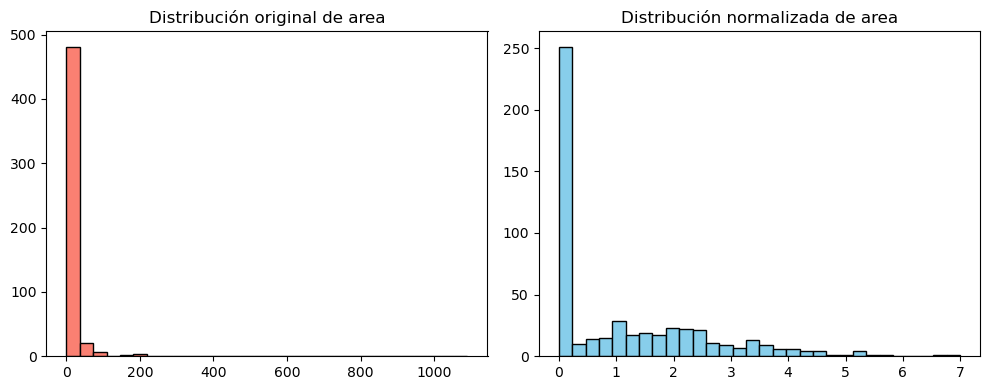

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(df['area'], bins=30, color='salmon', edgecolor='black')
ax[0].set_title('Distribución original de area')

ax[1].hist(df['area_norm'], bins=30, color='skyblue', edgecolor='black')
ax[1].set_title('Distribución normalizada de area')

plt.tight_layout()
plt.show()

In [15]:
X = df.drop(['area', 'area_norm'], axis=1)
Y = df['area_norm']

In [16]:
X_encoded = pd.get_dummies(X, columns=['month', 'day'], drop_first=True)

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_encoded, Y, test_size=0.3, random_state=42
)

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
svr_model = SVR(kernel='rbf', C=1000, gamma='scale', epsilon=0.1)
svr_model.fit(X_train_scaled, Y_train)

SVR(C=1000)

In [20]:
Y_pred_ln = svr_model.predict(X_test_scaled)

In [21]:
Y_pred_original = np.expm1(Y_pred_ln)
Y_test_original = np.expm1(Y_test)

In [22]:
rmse_original = np.sqrt(mean_squared_error(Y_test_original, Y_pred_original))
r2_original = r2_score(Y_test_original, Y_pred_original)

print(f"RMSE del Área Quemada (escala original): {rmse_original:.2f}")
print(f"R-cuadrado del Área Quemada (escala original): {r2_original:.4f}")

RMSE del Área Quemada (escala original): 102.63
R-cuadrado del Área Quemada (escala original): -0.3235


Numéricas usadas: ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']
Categóricas usadas: ['month', 'day']
Fitting 5 folds for each of 80 candidates, totalling 400 fits


/home/anahi/anaconda3/lib/python3.13/site-packages/sklearn/compose/_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(
/home/anahi/anaconda3/lib/python3.13/site-packages/sklearn/compose/_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(
/home/anahi/anaconda3/lib/python3.13/site-packages/sklearn/compose/_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(
/home/anahi/anaconda3/lib/python3.13/site-packages/sklearn/compose/_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to pro


[CV] END regressor__svr__C=10, regressor__svr__epsilon=0.01, regressor__svr__gamma=1, regressor__svr__kernel=rbf; total time=   0.0s
[CV] END regressor__svr__C=10, regressor__svr__epsilon=0.01, regressor__svr__gamma=1, regressor__svr__kernel=rbf; total time=   0.0s
[CV] END regressor__svr__C=10, regressor__svr__epsilon=0.01, regressor__svr__gamma=1, regressor__svr__kernel=rbf; total time=   0.1s
[CV] END regressor__svr__C=10, regressor__svr__epsilon=0.01, regressor__svr__gamma=1, regressor__svr__kernel=rbf; total time=   0.0s
[CV] END regressor__svr__C=10, regressor__svr__epsilon=0.1, regressor__svr__gamma=1, regressor__svr__kernel=rbf; total time=   0.0s
[CV] END regressor__svr__C=10, regressor__svr__epsilon=0.1, regressor__svr__gamma=1, regressor__svr__kernel=rbf; total time=   0.0s
[CV] END regressor__svr__C=10, regressor__svr__epsilon=0.5, regressor__svr__gamma=scale, regressor__svr__kernel=rbf; total time=   0.1s
[CV] END regressor__svr__C=10, regressor__svr__epsilon=0.5, regress

/home/anahi/anaconda3/lib/python3.13/site-packages/sklearn/compose/_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(
/home/anahi/anaconda3/lib/python3.13/site-packages/sklearn/compose/_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(
/home/anahi/anaconda3/lib/python3.13/site-packages/sklearn/compose/_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(
/home/anahi/anaconda3/lib/python3.13/site-packages/sklearn/compose/_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to pro


[CV] END regressor__svr__C=10, regressor__svr__epsilon=0.5, regressor__svr__gamma=0.1, regressor__svr__kernel=rbf; total time=   0.1s
[CV] END regressor__svr__C=10, regressor__svr__epsilon=0.5, regressor__svr__gamma=0.1, regressor__svr__kernel=rbf; total time=   0.1s
[CV] END regressor__svr__C=10, regressor__svr__epsilon=1, regressor__svr__gamma=1, regressor__svr__kernel=rbf; total time=   0.0s
[CV] END regressor__svr__C=10, regressor__svr__epsilon=1, regressor__svr__gamma=1, regressor__svr__kernel=rbf; total time=   0.0s
[CV] END regressor__svr__C=10, regressor__svr__epsilon=1, regressor__svr__gamma=1, regressor__svr__kernel=rbf; total time=   0.0s
[CV] END regressor__svr__C=10, regressor__svr__epsilon=1, regressor__svr__gamma=1, regressor__svr__kernel=rbf; total time=   0.0s
[CV] END regressor__svr__C=100, regressor__svr__epsilon=0.1, regressor__svr__gamma=scale, regressor__svr__kernel=rbf; total time=   0.1s
[CV] END regressor__svr__C=100, regressor__svr__epsilon=0.1, regressor__sv

/home/anahi/anaconda3/lib/python3.13/site-packages/sklearn/compose/_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(
/home/anahi/anaconda3/lib/python3.13/site-packages/sklearn/compose/_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(
/home/anahi/anaconda3/lib/python3.13/site-packages/sklearn/compose/_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(
/home/anahi/anaconda3/lib/python3.13/site-packages/sklearn/compose/_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to pro


[CV] END regressor__svr__C=10, regressor__svr__epsilon=0.5, regressor__svr__gamma=auto, regressor__svr__kernel=rbf; total time=   0.1s
[CV] END regressor__svr__C=10, regressor__svr__epsilon=0.5, regressor__svr__gamma=auto, regressor__svr__kernel=rbf; total time=   0.1s
[CV] END regressor__svr__C=10, regressor__svr__epsilon=0.5, regressor__svr__gamma=auto, regressor__svr__kernel=rbf; total time=   0.1s
[CV] END regressor__svr__C=10, regressor__svr__epsilon=0.5, regressor__svr__gamma=auto, regressor__svr__kernel=rbf; total time=   0.1s
[CV] END regressor__svr__C=100, regressor__svr__epsilon=0.01, regressor__svr__gamma=0.01, regressor__svr__kernel=rbf; total time=   0.1s
[CV] END regressor__svr__C=100, regressor__svr__epsilon=0.01, regressor__svr__gamma=0.01, regressor__svr__kernel=rbf; total time=   0.1s
[CV] END regressor__svr__C=100, regressor__svr__epsilon=0.01, regressor__svr__gamma=0.01, regressor__svr__kernel=rbf; total time=   0.1s
[CV] END regressor__svr__C=100, regressor__svr__

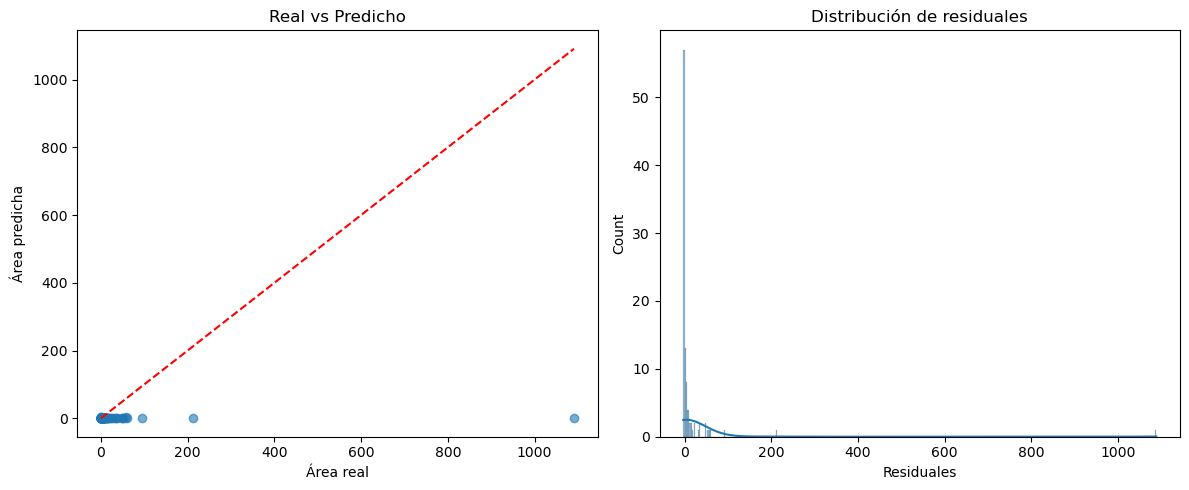

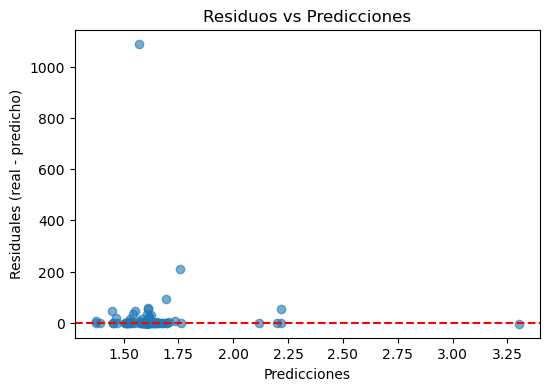


Modelo guardado como 'svr_forestfires_best.joblib'

Validación cruzada (R² en 5 folds): [ 0.         -0.1631624  -0.07834627 -0.12482778 -0.04784611]
Promedio R²: -0.08283651115887065


In [28]:
# 0) Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.compose import TransformedTargetRegressor
import sklearn
import joblib

import warnings
warnings.filterwarnings("ignore")

# 1) Cargar datos
df = pd.read_csv('../Dataset/forest+fires/forestfires.csv')

# 2) Seleccionar X e y
target_col = 'area'

if target_col not in df.columns:
    raise ValueError(f"No existe la columna '{target_col}' en el DataFrame.")

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

categorical_candidates = ['month', 'day']
categorical_cols = [c for c in categorical_candidates if c in df.columns]

print("Numéricas usadas:", numeric_cols)
print("Categóricas usadas:", categorical_cols)

X = df[numeric_cols + categorical_cols].copy()
y = df[target_col].copy()  # se convertirá a ndarray dentro del target

# 3) Preprocesamiento
if sklearn.__version__ >= '1.2':
    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
else:
    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
    ])

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
], remainder='drop')

# 4) Pipeline con SVR
svr = SVR()

pipeline = Pipeline(steps=[
    ('preproc', preprocessor),
    ('svr', svr)
])

# 4b) Transformación log + Z-score del target (robusta a 1D/2D)
target_transformer = Pipeline([
    ('log', FunctionTransformer(np.log1p, validate=True)),
    ('scale', StandardScaler())
])

def target_func(y):
    y = np.array(y).reshape(-1,1)  # asegura 2D
    return target_scaler.fit_transform(y).flatten()

def target_inverse_func(y):
    y = np.array(y).reshape(-1,1)
    return np.expm1(target_scaler.inverse_transform(y).flatten())

ttr = TransformedTargetRegressor(
    regressor=pipeline,
    transformer=target_transformer # TTR se encarga del reshape 1D/2D
)

# 5) Separar train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6) Definir grilla de hiperparámetros
param_grid = {
    'regressor__svr__kernel': ['rbf'],
    'regressor__svr__C': [0.1, 1, 10, 100],
    'regressor__svr__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'regressor__svr__epsilon': [0.01, 0.1, 0.5, 1]
}

# 7) Búsqueda de hiperparámetros
gscv = GridSearchCV(
    ttr,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

# 8) Entrenar modelo
gscv.fit(X_train, y_train)

print("Mejor score (neg RMSE):", gscv.best_score_)
print("Mejores parámetros:", gscv.best_params_)

# 9) Evaluar en test
best_model = gscv.best_estimator_
y_pred = best_model.predict(X_test)

# RMSE compatible con versiones antiguas
try:
    rmse = mean_squared_error(y_test, y_pred, squared=False)
except TypeError:
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"\n🔹 Test R²: {r2:.4f}")
print(f"🔹 Test RMSE: {rmse:.4f}")

# 10) Visualizaciones
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Área real')
plt.ylabel('Área predicha')
plt.title('Real vs Predicho')

plt.subplot(1,2,2)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.title('Distribución de residuales')
plt.xlabel('Residuales')

plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicciones')
plt.ylabel('Residuales (real - predicho)')
plt.title('Residuos vs Predicciones')
plt.show()

# 11) Guardar modelo
joblib.dump(best_model, 'svr_forestfires_best.joblib')
print("\nModelo guardado como 'svr_forestfires_best.joblib'")

# 12) Cross-validation adicional
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')
print("\nValidación cruzada (R² en 5 folds):", cv_scores)
print("Promedio R²:", np.mean(cv_scores))
